In [627]:
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
X = iris.data
y = iris.target
print('Class labels:', np.unique(y))
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

Class labels: [0 1 2]
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


In [628]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)
print('Labels count in y:', np.bincount(y))
print('Labels count in y_train:', np.bincount(y_train))
print('Labels count in y_test:', np.bincount(y_test))
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
# X_train_std = sc.transform(X_train)
# X_test_std = sc.transform(X_test)

Labels count in y: [50 50 50]
Labels count in y_train: [35 35 35]
Labels count in y_test: [15 15 15]


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


[Text(0.25, 0.9, 'x[3] <= 0.75\ngini = 0.667\nsamples = 105\nvalue = [35, 35, 35]'),
 Text(0.125, 0.7, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.1875, 0.8, 'True  '),
 Text(0.375, 0.7, 'x[2] <= 4.75\ngini = 0.5\nsamples = 70\nvalue = [0, 35, 35]'),
 Text(0.3125, 0.8, '  False'),
 Text(0.25, 0.5, 'gini = 0.0\nsamples = 30\nvalue = [0, 30, 0]'),
 Text(0.5, 0.5, 'x[3] <= 1.75\ngini = 0.219\nsamples = 40\nvalue = [0, 5, 35]'),
 Text(0.25, 0.3, 'x[2] <= 4.95\ngini = 0.5\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.125, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2, 0]'),
 Text(0.375, 0.1, 'gini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.75, 0.3, 'x[2] <= 4.85\ngini = 0.061\nsamples = 32\nvalue = [0, 1, 31]'),
 Text(0.625, 0.1, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.875, 0.1, 'gini = 0.0\nsamples = 29\nvalue = [0, 0, 29]')]

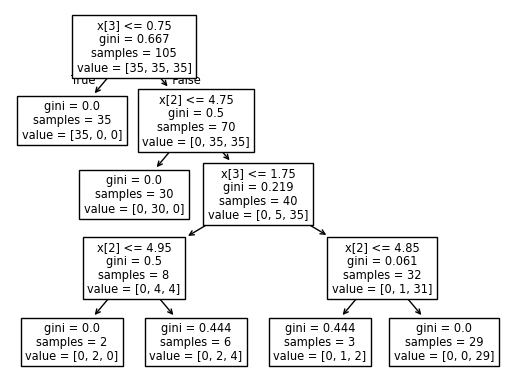

In [629]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(criterion='gini', 
                                    max_depth=4,
                                    splitter="best",
                                    random_state=1)
tree_model.fit(X_train, y_train)
from sklearn import tree

tree.plot_tree(tree_model)

In [630]:
y_pred=tree_model.predict(X_test)
accuracy=1-(y_test != y_pred).sum()/len(y_test)
print(f'accuracy: %d ' % (accuracy*100))
from sklearn.metrics import accuracy_score
print('accuracy: %.3f' % accuracy_score(y_test, y_pred))

accuracy: 97 
accuracy: 0.978


In [631]:
y_pred=tree_model.predict(X_train)
accuracy=1-(y_train != y_pred).sum()/len(y_train)
print(f'accuracy: %d ' % (accuracy*100))

accuracy: 97 


In [665]:
from itertools import combinations
import pandas as pd
from anytree import Node, RenderTree
class DecisionTree_C():
    def __init__(self, *,max_depth):
        self.tree_node=None         # 根節點
        self.max_depth_=max_depth # 最多樹狀層次
        self.depth_count_ = 0       # 目前樹狀層次
    class Tree_node():
        def __init__(self,node_type="root",feature=None,threshold=None,
                     is_leaf=False,left_child=None,right_child=None,
                     impurity=1,value=[]):
            self.node_type = node_type
            self.feature = feature
            self.is_leaf = is_leaf
            self.threshold = threshold
            self.left_child = left_child
            self.right_child = right_child
            self.impurity = impurity
            self.value = value
            self.prediction = None

        def _prediction(self,sample:np.ndarray):
            # 如果是葉節點
            if self.is_leaf:
                z=np.where(self.value >0) # tree_node.prediction  # 返回多數類或平均值
                return z
            else:
                # 否则是内部節點
                feature_value = sample[self.feature]  # 樣本該節點的特徵值
                threshold = self.threshold 
                # 根据判断走向左或右子節點
                if feature_value <= threshold:
                   return self.left_child._prediction(sample)
                else:
                   return self.right_child._prediction(sample)
        def plot(self):
            def break_down(treeNode,node:Node=None):
                name = f"gini = {treeNode.impurity}\nsamples = {sum(treeNode.value)}\nvalue = {treeNode.value}"
                if ((treeNode.left_child is not None) or (treeNode.right_child is not None)):
                    name = f"X[{treeNode.feature}]<={treeNode.threshold}\n"+name
                
                child = Node(name=name, parent=node) 
                if (treeNode.left_child is not None):
                    break_down(treeNode.left_child,child)
                if (treeNode.right_child is not None):
                    break_down(treeNode.right_child,child)
                
            root = Node(name=f"X[{self.feature}]<={self.threshold}\ngini = {self.impurity}\nsamples = {sum(self.value)}\nvalue = {self.value}")
            if (self.left_child is not None):
                break_down(self.left_child,root)
            if (self.right_child is not None):
                break_down(self.right_child,root)
            for pre, fill, node in RenderTree(root):
                # 將name分割成多行
                lines = node.name.split('\n')
                
                # 'pre' 是第一行
                print(f"{pre}{lines[0]}")
                
                # 'fill' 是其它行
                for line in lines[1:]:
                    print(f"{fill}{line}")         
        def __str__(self):  # print 物件專用
            return (f"'featrure':{self.feature},'threshold':{self.threshold},"
            f"'impurity':{self.impurity},'is_leaf':{self.impurity==0},'samples':{sum(self.value)},"
            f"'value':{self.value}")
        
    def _check_overlap(self,start1, end1, start2, end2):  # 判斷 類別1與2之間的feature是否有重疊
        return not (end1 < start2 or end2 < start1)        
    def fit(self,X,y):
        self.size_=len(np.unique(y))    # 類別數
        dataset=np.hstack((X,y.reshape(y.shape[0],1)))    # 對齊X、y給予合併
        root_node_impurity=self._gini_impurity(dataset)  
        self.tree_node=self.Tree_node(impurity=root_node_impurity,is_leaf=(root_node_impurity==0),
                                      value=np.bincount(y))
        self._break_down(dataset,self.tree_node,self.depth_count_)
        self.is_fitted_ = True
        return self.tree_node
    def _candidate_threshold(self,dataset:np.ndarray,feature)->list : # 可能的分割點        
        res=set()   
        ds=dataset[:,(feature,-1)]  # 取dataset中特徵值、類別值
        ind = np.lexsort((ds[:, 1], ds[:, 0]))  # 索引指標依特徵值+類別排序
        data=ds[ind]            # 排序後資料集
        for c in combinations(np.unique(dataset[:,-1]),2):
            cd= data[:,-1]==c[0]    # 設條件
            start_idx_0 = np.argmin(data[cd][:,0])  #  符合條件的起始指標
            min0=data[cd][:,0][start_idx_0]         #  符合條件的最小值
            end_idx_0 = np.argmax(data[cd][:,0])    #  符合條件的截止指標
            max0=data[cd][:,0][end_idx_0]           #  符合條件的最大值

            cd= data[:,-1]==c[1]    # 設條件
            start_idx_1 = np.argmin(data[cd][:,0])  #  符合條件的起始指標
            min1=data[cd][:,0][start_idx_1]         #  符合條件的最小值
            end_idx_1 = np.argmax(data[cd][:,0])    #  符合條件的截止指標
            max1=data[cd][:,0][end_idx_1]           #  符合條件的最大值
                    
            if not (self._check_overlap(min0,max0,min1,max1)):    # feature沒有重疊
                x=(min1+max0)/2 if min1>max0 else (min0+max1)/2     # 取兩個feature間的中間值為可能值
                res.add(x)
            else :
                start = min(min0,min1)
                end = max(max0,max1)
                cd = (data[:,0]>=start)  &  (data[:,0]<=end)
                dt = data[cd] 
                for row in dt:
                     cd1 = (dt[:,-1]!=row[-1]) & (dt[:,0] < row[0])
                     if (dt[cd1].size !=0):
                        tmpdt=dt[cd1]
                        pr = dt[np.argmax(tmpdt[:,0])]
                        res.add((pr[0]+row[0])/2)
        return list(res)
    def _gini_split(self,dataset:np.ndarray,threshold,feature)->dict: # 左右Gini 不純度
        result={}
        subset=dataset[dataset[:,feature]<=threshold]
        result['left']=self._gini_impurity(subset)
        subset=dataset[dataset[:,feature]>threshold]
        result['right']=self._gini_impurity(subset)
        return result
    def _weighted_gini(self,dataset:np.ndarray,threshold,feature):    # 加權後的 Gini (分割指標)，期望值
        splited_gini=self._gini_split(dataset,threshold,feature)
        N_p = dataset.shape[0]   # 子集分割前樣本數
        N_l = dataset[dataset[:,feature]<=threshold].shape[0]    # 分割後左節點樣本數
        N_r = dataset[dataset[:,feature]>threshold].shape[0]     # 分割後右節點樣本數
        I_l = splited_gini["left"]       # 左節點不純度
        I_r = splited_gini["right"]      # 右節點不純度
        return N_l/N_p*I_l + N_r/N_p*I_r
        
    def _gini_impurity(self,subset:np.ndarray):     # 計算節點(node)的Gini 不純度(impurity)                    
        I=1
        for c in np.unique(subset[:-1]):    # 1-各類別比例的平方
            I-=(subset[subset[:,-1]==c].shape[0]/subset.shape[0])**2
        return I
    def _break_down(self,dataset,node:Tree_node,depth_count):
        if node.is_leaf or depth_count >= self.max_depth_:
            return
        impurity = 1        
        # for f in reversed(range(dataset.shape[1]-1)):  # 對每一個feature處理
        for f in range(dataset.shape[1]-1):  # 對每一個feature處理
            splitters=self._candidate_threshold(dataset=dataset,feature=f)    # 候選分割點
            
            for splitter in splitters:     # 可能的閾值
                weighted=self._weighted_gini(     # 計算閾值區分左右子集後之權重gini不純度
                    dataset,
                    threshold=splitter,
                    feature=f)    
                if (weighted<impurity):   # 尋求最小gini 不純度
                    impurity=weighted
                    node.feature=f
                    node.threshold=splitter
        # print(f"parent node-->{node}")        
        left_subset=dataset[dataset[:,node.feature]<=node.threshold]
        left_impurity=self._gini_impurity(left_subset)
        node.left_child=self.Tree_node(impurity=left_impurity,is_leaf=(left_impurity==0),
                                       value=np.bincount(left_subset[:,-1].reshape(-1).astype(np.int64),minlength=self.size_))
        # print(f"left node-->{node.left_child}")
        right_subset=dataset[dataset[:,node.feature]>node.threshold]
        right_impurity=self._gini_impurity(right_subset)
        node.right_child=self.Tree_node(impurity=right_impurity,is_leaf=(right_impurity==0),
                                        value=np.bincount(right_subset[:,-1].reshape(-1).astype(np.int64),minlength=self.size_))   
        # print(f"right node-->{node.right_child}")
        depth_count +=1
        if (not node.right_child.is_leaf):
            self._break_down(right_subset,node.right_child,depth_count)
        if (not node.left_child.is_leaf):
            self._break_down(left_subset,node.left_child,depth_count)
    
    def predict(self,tree_node:Tree_node, samples)->np.ndarray:
        result = np.array([])
        for sample in samples:
            label = tree_node._prediction(sample)
            result = np.append(result,label)
        return result
            

In [666]:
dtc=DecisionTree_C(max_depth=4)
rootnode=dtc.fit(X_train,y_train)
rootnode.plot()

X[2]<=2.5999999999999996
gini = 0.6666666666666665
samples = 105
value = [35 35 35]
├── gini = 0.0
│   samples = 35
│   value = [35  0  0]
└── X[2]<=4.75
    gini = 0.5
    samples = 70
    value = [ 0 35 35]
    ├── gini = 0.0
    │   samples = 30
    │   value = [ 0 30  0]
    └── X[3]<=1.7
        gini = 0.21875
        samples = 40
        value = [ 0  5 35]
        ├── X[2]<=4.95
        │   gini = 0.5
        │   samples = 8
        │   value = [0 4 4]
        │   ├── gini = 0.0
        │   │   samples = 2
        │   │   value = [0 2 0]
        │   └── gini = 0.4444444444444444
        │       samples = 6
        │       value = [0 2 4]
        └── X[2]<=4.85
            gini = 0.060546875
            samples = 32
            value = [ 0  1 31]
            ├── gini = 0.5555555555555556
            │   samples = 3
            │   value = [0 1 2]
            └── gini = 0.0
                samples = 29
                value = [ 0  0 29]


In [667]:
y_pred=dtc.predict(dtc.tree_node,X_test)
accuracy=1-(y_test != y_pred).sum()/len(y_test)
print(f'accuracy: %d ' % (accuracy*100))
print('accuracy: %.3f' % accuracy_score(y_test, y_pred))

accuracy: 97 
accuracy: 0.978
